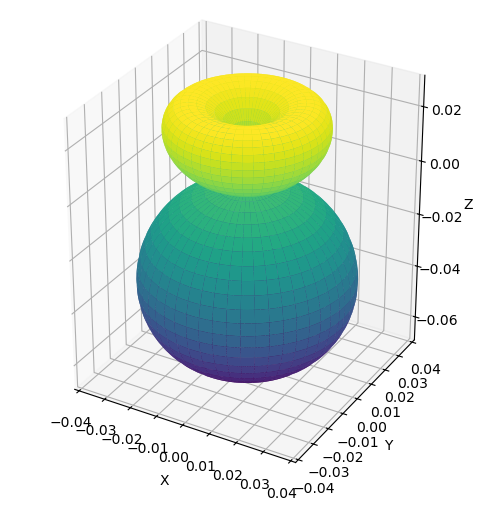

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm_y, genlaguerre
import math
a = 1  # Bohr radius

r = np.linspace(0, 3 * a, 200)
theta, phi = np.meshgrid(np.linspace(0, np.pi, 200), np.linspace(0, 2 * np.pi, 200))

def radial(n, l, r):
    rho = 2 * r / (n * a)
    norm = np.sqrt((2 / (n * a))**3 * math.factorial(n - l - 1) / (2 * n * math.factorial(n + l)))
    laguerre = genlaguerre(n - l - 1, 2 * l + 1)(rho)
    R = norm * np.exp(-rho / 2) * rho**l * laguerre
    return R

def angular(l,m):
    Y = sph_harm_y(l, m, theta, phi)
    if m == 0:
        return Y
    elif m > 0:
        Y_real = Y.real
        return Y_real
    else:
        Y_imag = Y.imag
        return Y_imag

radial_part = radial(2, 1, r)
angular_part = angular(1,0)
# wavefunction = radial_part * angular_part
# e_density = np.abs(wavefunction)**2

x = radial_part * np.sin(theta) * np.cos(phi)
y = radial_part * np.sin(theta) * np.sin(phi)
z = radial_part * np.cos(theta)

X, Y, Z = x * np.abs(angular_part), y * np.abs(angular_part), z * np.abs(angular_part)

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1,1,1, projection = '3d')
ax.plot_surface(X,Y,Z,cmap='viridis')
ax.set_aspect('equal')
ax.set(xlabel='X', ylabel='Y', zlabel='Z')

plt.show()
